In [18]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import scipy.linalg as la
import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian_v2 import *
from scripts.self_consistency_v2 import *


In [23]:
X, Y = 50, 50
lattice = Lattice(X, Y)

t = 1
mu = -2 * t * np.ones(lattice.X)

U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 2.0 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, U=None, V_prime=V_prime, V=None, Fuu_init= [0.1, -0.1, 0.1j, -0.1j])

In [24]:
print(is_hermitian(H.matrix))
print(is_hermitian(H.build_Hk(PI/3)))

True
True


In [25]:
bdg_self_consistency(H, maxiter=200, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS

Iteration 1:
F0:
Absolute error: 5.954128367740943e-15
Relative error: 0.005954128367740942
Average_old: 0j
Average_new: (-2.7174623933668484e-16+0j)
F_xplus:
Absolute error: 4.73290471367594e-17
Relative error: 4.732904713675941e-05
Average_old: 0j
Average_new: (7.016772747234923e-19+0j)
F_xmin:
Absolute error: 5.308811516297121e-17
Relative error: 5.308811516297121e-05
Average_old: 0j
Average_new: (8.105014337326228e-19+0j)
F_yplus:
Absolute error: 5.956374418098764e-15
Relative error: 0.005956374418098764
Average_old: 0j
Average_new: (-2.7153272244967294e-16-1.089947222609029e-19j)
F_ymin:
Absolute error: 5.956374418098764e-15
Relative error: 0.005956374418098764
Average_old: 0j
Average_new: (-2.7153272244967294e-16+1.089947222609029e-19j)
Fuu_xplus:
Absolute error: 0.6824377342595599
Relative error: 6.824377342527354
Average_old: (0.09999999999999998+0j)
Average_new: (0.0025091678954741858+0j)
Fuu_xmin:
Absolute error: 0.6824377342595596
Relative error: 6.824377342663839
Average_ol

In [26]:
bdg_self_consistency(H, maxiter=1, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS


Iteration 1:
F0:
Absolute error: 5.681211932549927e-17
Relative error: 5.681189900370602e-05
Average_old: (1.91816471074254e-18+0j)
Average_new: (1.0503771018407523e-18+0j)
F_xplus:
Absolute error: 4.006673222484576e-17
Relative error: 4.0066698770986765e-05
Average_old: (2.262547862044718e-19+0j)
Average_new: (-5.079616819832452e-19+0j)
F_xmin:
Absolute error: 4.7680728880147157e-17
Relative error: 4.7680614489771794e-05
Average_old: (1.2762825329061085e-18+0j)
Average_new: (-2.05575904462531e-20+0j)
F_yplus:
Absolute error: 5.708146696352951e-17
Relative error: 5.7081462952133935e-05
Average_old: (-3.1289689587935813e-19+1.49110876827377e-18j)
Average_new: (3.6462152618222047e-19+9.91617515178699e-19j)
F_ymin:
Absolute error: 5.708146696352951e-17
Relative error: 5.7081462952133935e-05
Average_old: (-3.1289689587935813e-19-1.49110876827377e-18j)
Average_new: (3.6462152618222047e-19-9.91617515178699e-19j)
Fuu_xplus:
Absolute error: 3.282141376476138e-15
Relative error: 0.0032802662850

In [27]:
print(is_hermitian(H.build_Hk(PI/4)))
print(is_hermitian(H.matrix))
print(np.mean(H.F0))

True
True
(1.0503771018407523e-18+0j)


In [28]:
F0, F_xplus, F_xmin, F_yplus, F_ymin,\
Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,\
Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin= H.get_correlations()

In [32]:
Nx = F_yplus.shape[0]  # number of x sites

Fx_p = np.zeros(Nx, dtype=complex)
Fx_m = np.zeros(Nx, dtype=complex)
Fx_p[:-1] = Fuu_xplus      # site i gets bond (i,i+1)
Fx_m[1:]  = Fuu_xmin       # site i gets bond (i,i-1).T

print(np.mean(Fx_p - Fx_m)/2)
print(np.mean(Fuu_yplus - Fuu_ymin)/2)
print(np.mean(Fx_p + Fx_m - F_yplus - F_ymin)/4)
print(np.mean(Fx_p + Fx_m + F_yplus + F_ymin)/4)

(1.6970490498056305e-17+0j)
5.708260795525139e-19j
(4.936460889968892e-19+0j)
(8.582676151791098e-19+0j)


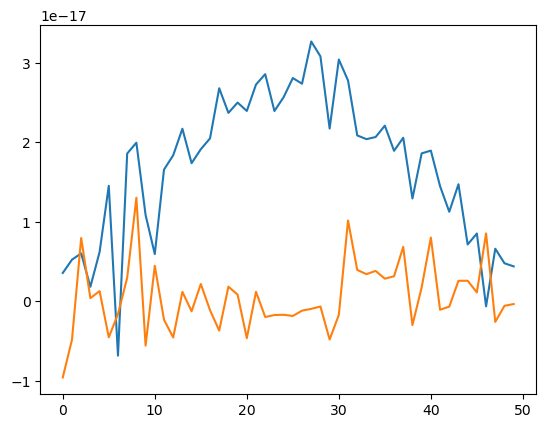

In [33]:
plt.plot(np.real(Fx_p - Fx_m)/2)
plt.plot(np.imag(Fuu_yplus - Fuu_ymin)/2)

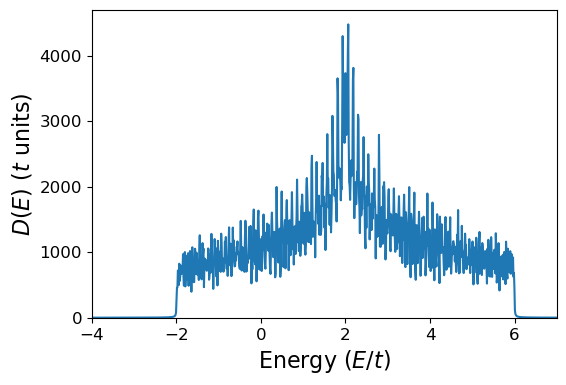

In [31]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.0051)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
print(H.free_energy(0))

In [ ]:
# %prun H.dos(energies, eta=1e-3)